# Amelioration du modele - interactions + approche en deux etages

**Point 1** : ajout d'interactions entre features (budget x franchise, etc.)
**Point 2** : modele en deux etages -- classifier les echecs extremes, puis regresser le reste.

## 1. Chargement et rappel du modele de reference (LightGBM tune)

In [1]:
import sys
sys.path.append("../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, RandomizedSearchCV
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, classification_report
from sklearn.linear_model import LogisticRegression
from lightgbm import LGBMRegressor, LGBMClassifier

from boxoffice.modeling.features_ml import load_model_data, NUMERIC_FEATURES

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

X, y_class, y_reg, feature_names = load_model_data()
print(f"X: {X.shape}, y_reg: {y_reg.shape}")

[features_ml] 5 lignes avec NaN residuel exclues.
X: (9263, 36), y_reg: (9263,)


## 2. Point 1 -- Ajout d'interactions entre features

On cible des interactions avec une justification metier claire (pas de croisement aveugle) :
- `budget x is_franchise` : un gros budget sur une franchise etablie n'a pas le meme effet
  qu'un gros budget sur un film original.
- `budget x genre_Animation` : economie de production differente (studios dedies, cout marginal
  different d'un blockbuster live-action).
- `n_cast x is_franchise` : un casting large sur une franchise capitalise sur des personnages
  connus, sur un film original c'est un signal different (superproduction risquee).

In [2]:
X_enriched = X.copy()

X_enriched["budget_x_franchise"] = X["log_budget"] * X["is_franchise"]
X_enriched["budget_x_animation"] = X["log_budget"] * X["genre_Animation"]
X_enriched["cast_x_franchise"] = X["n_cast"] * X["is_franchise"]
X_enriched["director_x_cast_hits"] = X["director_taux_hits_avant"] * X["cast_taux_hits_avant"]

feature_names_enriched = X_enriched.columns.tolist()
print(f"Features avant: {len(feature_names)}, apres enrichissement: {len(feature_names_enriched)}")
print("Nouvelles colonnes:", [c for c in feature_names_enriched if c not in feature_names])

Features avant: 36, apres enrichissement: 40
Nouvelles colonnes: ['budget_x_franchise', 'budget_x_animation', 'cast_x_franchise', 'director_x_cast_hits']


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X_enriched, y_reg, test_size=0.2, random_state=RANDOM_STATE
)

lgbm_enriched = LGBMRegressor(
    n_estimators=500, max_depth=4, learning_rate=0.03, subsample=0.8,
    colsample_bytree=0.6, num_leaves=31, random_state=RANDOM_STATE, n_jobs=-1, verbose=-1
)
lgbm_enriched.fit(X_train, y_train)
y_pred_enriched = lgbm_enriched.predict(X_test)

r2_enriched = r2_score(y_test, y_pred_enriched)
rmse_enriched = np.sqrt(mean_squared_error(y_test, y_pred_enriched))
mae_enriched = mean_absolute_error(y_test, y_pred_enriched)

print(f"LightGBM + interactions   R2={r2_enriched:.3f}  RMSE={rmse_enriched:.3f}  MAE={mae_enriched:.3f}")
print(f"(reference sans interactions: R2=0.165  RMSE=1.580  MAE=1.136)")

LightGBM + interactions   R2=0.156  RMSE=1.588  MAE=1.139
(reference sans interactions: R2=0.165  RMSE=1.580  MAE=1.136)


In [ ]:
import shap

explainer = shap.TreeExplainer(lgbm_enriched)
shap_values = explainer.shap_values(X_test)

mean_abs_shap = pd.Series(np.abs(shap_values).mean(axis=0), index=feature_names_enriched).sort_values(ascending=False)
print("Top 10 features (avec interactions) par importance SHAP:")
print(mean_abs_shap.head(10))

#dash -> résultats roi prédiction positif negatif - utilisateur qui clique puis recommandation
#jouer sur la variable 

Top 10 features (avec interactions) par importance SHAP:
is_franchise                0.290178
runtime                     0.205414
n_cast                      0.200959
director_taux_hits_avant    0.175892
log_budget                  0.163488
age_min                     0.123437
cast_taux_hits_avant        0.117226
budget_x_franchise          0.083418
director_films_avant        0.074396
cast_x_franchise            0.060591
dtype: float64


## 3. Point 2 -- Modele en deux etages

**Etage A (classification)** : predire si un film est un "echec severe" (log_roi sous le
10e percentile, c'est-a-dire un ROI tres faible) vs le reste.

**Etage B (regression)** : entrainer un regressseur uniquement sur les films "non echec severe",
ou la relation budget/casting/genre -> ROI est plus reguliere et moins dominee par des cas
extremes impredictibles (ex. bad buzz, scandale, sortie desastreuse).

In [5]:
seuil_echec = y_reg.quantile(0.10)
print(f"Seuil d'echec severe (10e percentile de log_roi): {seuil_echec:.3f} (soit ROI = {np.exp(seuil_echec):.3f})")

y_echec_severe = (y_reg <= seuil_echec).astype(int)
print(f"Films en echec severe: {y_echec_severe.sum()} ({y_echec_severe.mean():.1%})")

Seuil d'echec severe (10e percentile de log_roi): -1.856 (soit ROI = 0.156)
Films en echec severe: 927 (10.0%)


In [6]:
X_train2, X_test2, y_train2, y_test2, y_echec_train, y_echec_test = train_test_split(
    X_enriched, y_reg, y_echec_severe, test_size=0.2, random_state=RANDOM_STATE, stratify=y_echec_severe
)

# Etage A : classifieur d'echec severe
clf_echec = LGBMClassifier(n_estimators=200, max_depth=4, learning_rate=0.05,
                            random_state=RANDOM_STATE, n_jobs=-1, verbose=-1)
clf_echec.fit(X_train2, y_echec_train)

y_echec_pred = clf_echec.predict(X_test2)
print(classification_report(y_echec_test, y_echec_pred, target_names=["Pas echec severe", "Echec severe"]))

                  precision    recall  f1-score   support

Pas echec severe       0.90      1.00      0.95      1668
    Echec severe       0.67      0.01      0.02       185

        accuracy                           0.90      1853
       macro avg       0.78      0.51      0.48      1853
    weighted avg       0.88      0.90      0.86      1853



In [7]:
# Etage B : regresseur entraine uniquement sur les films 'pas echec severe' du train
mask_train_ok = y_echec_train == 0
X_train_ok = X_train2[mask_train_ok]
y_train_ok = y_train2[mask_train_ok]

reg_stage2 = LGBMRegressor(n_estimators=500, max_depth=4, learning_rate=0.03, subsample=0.8,
                            colsample_bytree=0.6, num_leaves=31, random_state=RANDOM_STATE, n_jobs=-1, verbose=-1)
reg_stage2.fit(X_train_ok, y_train_ok)

print(f"Etage B entraine sur {len(X_train_ok)} films (hors echecs severes)")

Etage B entraine sur 6668 films (hors echecs severes)


In [8]:
# Prediction combinee sur le test complet :
# si le classifieur predit 'echec severe' -> on assigne directement le seuil d'echec
# sinon -> on utilise la prediction du regresseur etage B
y_pred_stage2 = np.where(
    y_echec_pred == 1,
    seuil_echec,
    reg_stage2.predict(X_test2)
)

r2_stage2 = r2_score(y_test2, y_pred_stage2)
rmse_stage2 = np.sqrt(mean_squared_error(y_test2, y_pred_stage2))
mae_stage2 = mean_absolute_error(y_test2, y_pred_stage2)

print(f"Modele deux etages       R2={r2_stage2:.3f}  RMSE={rmse_stage2:.3f}  MAE={mae_stage2:.3f}")
print(f"(reference LightGBM tune sans etages: R2=0.165  RMSE=1.580  MAE=1.136)")

Modele deux etages       R2=0.134  RMSE=1.588  MAE=1.108
(reference LightGBM tune sans etages: R2=0.165  RMSE=1.580  MAE=1.136)


## 4. Comparatif final : reference vs interactions vs deux etages

                    approche     R2   RMSE    MAE
0  LightGBM tune (reference)  0.165  1.580  1.136
1    LightGBM + interactions  0.156  1.588  1.139
2         Modele deux etages  0.134  1.588  1.108


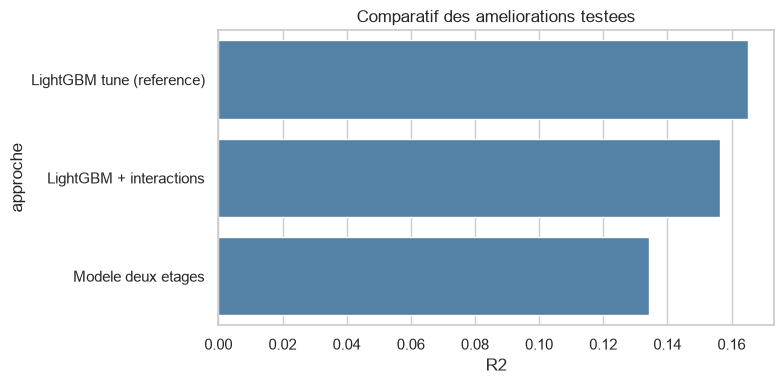

In [9]:
comparatif_final = pd.DataFrame([
    {"approche": "LightGBM tune (reference)", "R2": 0.165, "RMSE": 1.580, "MAE": 1.136},
    {"approche": "LightGBM + interactions", "R2": r2_enriched, "RMSE": rmse_enriched, "MAE": mae_enriched},
    {"approche": "Modele deux etages", "R2": r2_stage2, "RMSE": rmse_stage2, "MAE": mae_stage2},
]).sort_values("R2", ascending=False).reset_index(drop=True)

print(comparatif_final.round(3))

plt.figure(figsize=(8, 4))
sns.barplot(data=comparatif_final, x="R2", y="approche", color="steelblue")
plt.title("Comparatif des ameliorations testees")
plt.tight_layout()
plt.show()